## Exploration 4.Word Embeddings - Movie Corpus WEAT Analysis 

### Table of Contents
1. [Introduction](#1-introduction)
    * 1.1 [Concept and Definition of Word Embedding](#11-concept-and-definition-of-word-embedding)
    * 1.2 [Necessity and Objectives of Word Embedding](#12-necessity-and-objectives-of-word-embedding)
    * 1.3 [Word Embedding Construction Process and Methodologies](#13-word-embedding-construction-process-and-methodologies)
    * 1.4 [Corpus-based Model: Why a Specialized Movie Corpus?](#14-corpus-based-model-why-a-specialized-movie-corpus)
2. [Methodology](#2-methodology)
    * 2.1 [Understanding WEAT (Word Embedding Association Test)](#21-understanding-weat-word-embedding-association-test)
    * 2.2 [Definition and Selection Criteria for Target and Attribute Sets](#22-definition-and-selection-criteria-for-target-and-attribute-sets)
    * 2.3 [Numerical Significance and Calculation of WEAT Score](#23-numerical-significance-and-calculation-of-weat-score)
    * 2.4 [Research Objectives and Expected Effects](#24-research-objectives-and-expected-effects)
3. [Implementation](#3-implementation)
    * 3.1 [Corpus Preprocessing and Embedding Model Training](#31-corpus-preprocessing-and-embedding-model-training)
    * 3.2 [Generation and Refinement of Target and Attribute Word Sets](#32-generation-and-refinement-of-target-and-attribute-word-sets)
    * 3.3 [WEAT Score Calculation and Process Automation](#33-weat-score-calculation-and-process-automation)
    * 3.4 [Data Visualization and Result Extraction](#34-data-visualization-and-result-extraction)
4. [Result & Conclusion](#4-result--conclusion)
    * 4.1 [Interpretation of Bias Results by Genre](#41-interpretation-of-bias-results-by-genre)
    * 4.2 [Project Summary and Future Improvements](#43-project-summary-and-future-improvements)


## 1. Introduction

#### 1.1 Concept and Definition of Word Embedding
Word Embedding is the process of mapping discrete linguistic symbols into a continuous, low-dimensional vector space. To a computer, text strings are arbitrary sequences of characters with no inherent mathematical meaning. Embedding allows us to represent these symbols as dense tensors so that semantic relationships can be calculated through linear algebra.

##### **Comparison: Computer Vision (CV) vs. Natural Language Processing (NLP)**
It is a common misconception that CV does not require embedding because images are already "numerical." However, the nature of the "numbers" differs fundamentally:

* **In Computer Vision (CV):** 
  * An image starts as a 3D tensor of **Raw Data** (RGB pixel intensities). 
  * While these are numbers, they represent "signal" rather than "meaning." A pixel value of `255` doesn't "mean" anything until a model transforms it. 
  * In CV, we use neural networks to transform these raw pixels into **Feature Embeddings** (latent vectors) that represent high-level concepts like "texture" or "object shape."
* **In Natural Language Processing (NLP):** 
  * We start with **Discrete Symbols** (strings). There is no "raw signal" for the word "Movie." 
  * Unlike CV, where spatial proximity in pixels implies a relationship, words have no mathematical distance until we **explicitly create** a vector space. 
  * Word Embedding is the foundational step of assigning each symbol a coordinate so that "Movie" and "Film" occupy similar positions, allowing the computer to recognize them as semantically related.


##### **From Strings to Tensors: The Encoding Evolution**
To bridge the gap between strings and tensors, we must move beyond simple indexing to a multi-dimensional representation:
* **Beyond One-Hot Encoding:** 
    *  Traditionally, words were represented as **One-Hot Vectors**, where each word is a sparse vector with a `1` at its unique index and `0` everywhere else. 
    * **The Limitation:** In this format, every word is equidistant from every other word. Mathematically, the dot product (similarity) between "Movie" and "Film" is `0`, exactly the same as "Movie" and "Banana." It fails to capture any semantic nuance.
* **Dense Vector Mapping (Embedding):**
    * Instead of an index-based sparse vector, we assign each word to a **Dense Vector**—a sequence of real numbers (e.g., `[0.12, -0.59, 0.88, ...]`).
    * **Semantic Proximity:** The primary feature of this transformation is that words with shared contexts, such as **"Movie"** and **"Film,"** are forced to occupy **similar coordinates** in the $d$-dimensional space. 
    * **Mathematical Identity:** Because "Movie" and "Film" appear in similar environments (e.g., near words like "Director," "Scene," or "Watch"), the model updates their weights to be close to each other. This allows the computer to perform "semantic arithmetic" where the geometric distance directly reflects the human understanding of the words.


#### 1.2 Necessity and Objectives of Word Embedding
The transition from traditional One-Hot Encoding to Word Embedding is driven by the fundamental need for computational efficiency and semantic intelligence.

* **Overcoming the Curse of Dimensionality:**
    * In **One-Hot Encoding**, a vocabulary of 50,000 words requires 50,000-dimensional vectors. These vectors are "sparse," meaning they are mostly composed of zeros, which is computationally expensive and memory-inefficient.
    * **Word Embedding** performs **Dimensionality Reduction**, compressing this information into a **dense vector** (typically 100–300 dimensions). This allows the model to represent the same vocabulary in a much more compact and computationally manageable numerical space.
* **Capturing Latent Relationships via Context:**
    * The primary goal of embedding is to capture "context." By analyzing a **Corpus** (a structured collection of text), the model learns that words appearing in similar environments share semantic traits.
    * In a well-trained embedding space, the geometric relationship between vectors reflects human logic. This enables mathematical analogies such as:
        $$\text{vec(King)} - \text{vec(Man)} + \text{vec(Woman)} \approx \text{vec(Queen)}$$
* **Mathematical Metric (Cosine Similarity):**
    * To verify if the model has successfully internalized the semantic patterns of the given data, we measure the "distance" between word vectors.
    * We use **Cosine Similarity** to determine how closely related two words are in the high-dimensional space:
        $$\text{similarity} = \cos(\theta) = \frac{A \cdot B}{\|A\| \|B\|}$$
    * A high similarity score (closer to 1.0) indicates that the words frequently share context within the corpus, proving the model has successfully mapped the linguistic relationship into a numerical tensor.

#### 1.3 Word Embedding Construction Process and Methodologies

To achieve our goal of building a domain-specific model, we follow a rigorous three-step pipeline using a **Movie Corpus** (the specific rationale for using this corpus is detailed in Section 1.4).

**Step 1: Data Collection & Corpus Definition**
* Understanding the Corpus
  * What is a Corpus?
    * A corpus (plural: corpora) is a large, structured collection of machine-readable texts specifically gathered for linguistic analysis or model training. It is not just a random set of sentences; it is a curated dataset that represents how language is used within a particular domain.
  * Why a "Movie" Corpus?
    * An embedding model's "intelligence" is strictly limited by the data it consumes. By providing a specialized movie corpus, we ensure the model learns the specific vocabulary, jargon, and stylistic nuances used by film critics and audiences. Without a well-prepared corpus, the model would be unable to map semantic relationships accurately for movie-specific terms.
* Case Study: The Movie Synopsis Corpus
  * Definition of the Movie Synopsis Corpus
    * For this project, our Corpus is constructed from a vast collection of movie synopses. Each synopsis acts as a high-density information source containing key themes, character roles, and genre-specific vocabulary.
  * The Role of the Corpus
    * By using synopses as our primary data source, the model learns the structural relationships between cinematic concepts. For instance, the model observes how "Detective" frequently co-occurs with "Mystery" or "Investigation" within the synopsis text, allowing it to build a specialized semantic map of the film industry.

**Step 2: Preprocessing (The Foundation of Quality)**
1.  **Tokenization & POS Tagging:** Text is broken down into its smallest meaningful units (morphemes). In Korean, extracting the "stem" of a word is crucial to ensure that different grammatical forms of the same word (e.g., "영화가", "영화는") are treated as a single semantic entity.
2.  **Stop-word Removal:** Words with high frequency but low semantic value (e.g., "is," "the," "and") are filtered out to reduce noise and improve the quality of the resulting vectors.

**Step 3: Detailed Architectural Comparison and Selection**
* While several architectures exist for word embedding, they differ in how they process the input data and optimize the vector space:

  * **Word2Vec (Shallow Neural Network):**
      * **Architecture:** A neural network consisting of an input layer, **one hidden layer (without an activation function)**, and an output layer. It acts as a bottleneck that forces the model to learn a compressed representation of word context.
      * **Methodologies:** Includes **Skip-gram** (predicting context from a target word) and **CBOW** (predicting a target word from context). 
      * **Selection:** In this project, we primarily utilize **Word2Vec** to construct our model, as it is highly effective at capturing semantic similarities in a well-defined domain like cinema.


  * **FastText (Sub-word Information):**
      * **Innovation:** Unlike Word2Vec, FastText treats words as a collection of **n-grams (sub-words)** rather than atomic units.
      * **Advantage:** By learning from sub-parts of words, it can effectively handle "Out-of-Vocabulary" (OOV) words and complex morphological variations, which is highly beneficial for the Korean language.

  * **GloVe (Global Vectors for Word Representation):**
      * **Architecture:** A count-based regression model that focuses on global co-occurrence statistics
      * **Mechanism:** It constructs a global co-occurrence matrix of the entire corpus and optimizes vectors so that their dot product captures the statistical ratio of word appearances.


#### 1.4 Corpus-based Model: Why a Specialized Movie Corpus?
In modern NLP, practitioners often choose between training a model from scratch or using **Pre-trained Models** (models already trained on massive, general datasets like Wikipedia or Google News). For this project, we have opted for a **Corpus-based Learning** approach using a specialized movie dataset.

##### **Comparison of Learning Approaches**
* **Pre-trained Models:** While they offer a broad foundation of general semantic knowledge, they often fail to capture the "long-tail" of domain-specific terminology. They represent a diluted version of general internet trends rather than the specific vocabulary of a niche field.
* **Corpus-based Learning (Our Choice):** By training specifically on a movie-related corpus, we ensure that the model internalizes the unique linguistic habits of movie critics and audiences.

##### **The Strategic Justification**
* **Domain-Specific Nuance:** A general model might understand "Action" as a physical movement or a legal proceeding. In contrast, a model trained on our **Movie Corpus** correctly identifies "Action" as a cinematic genre characterized by stunts and high-paced sequences. This ensures that the word associations are contextually accurate.
* **Targeted Bias Analysis:** The core of our WEAT analysis is to measure cultural perceptions within the film industry (e.g., Art vs. General films). To do this accurately, the model must learn its associations directly from the relevant source. Using our own corpus ensures that the resulting WEAT scores are a direct reflection of "Cinema Culture" rather than a generic social bias.
* **Achieving the "Normal" Model Goal:** One of our primary objectives is to demonstrate the successful construction of a "normally" functioning embedding model. By training from scratch, we prove that our preprocessing and training pipeline can produce a model where the `most_similar()` method yields results that align perfectly with movie-specific vocabulary.


## 2. Methodology


#### 2.1 Understanding WEAT (Word Embedding Association Test)

The Word Embedding Association Test (WEAT) was introduced to quantitatively measure the social and cultural biases embedded within word representation models.

* **The Origin: Embedding Bias**
    * As discussed in the introduction, word embeddings learn from human-generated corpora. If the training data contains historical prejudices, gender stereotypes, or cultural stigmas, the model mathematically encodes these as "proximity" between certain vectors.
    * **Example:** In many general models, the vector for "Doctor" is often found closer to "Man," while "Nurse" is closer to "Woman." This is not a logical necessity but a reflection of societal bias present in the text data.
* **The Necessity of a Metric**
    * While we can intuitively feel that a model is biased, we need a rigorous, statistical way to prove it. WEAT provides a standardized "score" to determine if Target A is more strongly associated with Attribute X than Target B is.
* **Core Logic: Differential Association**
    * WEAT operates on the principle that if a model is unbiased, the average distance between a neutral concept and two opposing attributes should be relatively equal. 
    * If there is a significant imbalance in these distances (measured by Cosine Similarity), it serves as mathematical evidence of **Embedding Bias**.


#### 2.2 Definition and Selection Criteria for Target and Attribute Sets
To perform a valid WEAT analysis, we must define four distinct sets of words. The accuracy of the test depends entirely on the quality and representativeness of these sets.

* **Target Sets ($X, Y$)**
    * These are the two contrasting groups we want to examine for bias.
    * In this project, our targets are categorized by cinematic value:
        * **Target $X$ (Art Movies):** Words representing independent, auteur-driven, or artistic films (e.g., *Auteur, Independent, Experimental*).
        * **Target $Y$ (General/Commercial Movies):** Words representing mainstream, mass-market films (e.g., *Blockbuster, Franchise, Box-office*).
* **Attribute Sets ($A, B$)**
    * These represent the "valence" or the "properties" we measure against the targets.
    * We typically use opposing concepts:
        * **Attribute $A$ (Positive/Artistic Traits):** Words like *Creative, Deep, Sophisticated, Beautiful*.
        * **Attribute $B$ (Negative/Generic Traits):** Words like *Boring, Simple, Repetitive, Commercial*.
* **Selection Criteria for Validity**
    * **Mutual Exclusivity:** A word in Set $X$ must not appear in Set $Y$.
    * **Representativeness:** Words must be high-frequency terms within our **Movie Synopsis Corpus** to ensure the model has a stable vector for them.
    * **Frequency Balancing:** We often use TF-IDF (Term Frequency-Inverse Document Frequency) or raw frequency counts to select words that are truly emblematic of their respective categories.



#### 2.3 Numerical Significance and Calculation of WEAT Score
To move from an intuitive feeling of bias to a scientific result, we use a multi-step mathematical process. This allows us to quantify the "Differential Association" between word groups.

**1. The Single Word Association Score: $s(w, A, B)$**

First, we calculate how much a single word $w$ (from our target sets) is associated with one attribute set over another.
    $$s(w, A, B) = \text{mean}_{a \in A} \cos(w, a) - \text{mean}_{b \in B} \cos(w, b)$$
  * **What it means:** We take the average cosine similarity of word $w$ with all words in Attribute $A$, and subtract the average similarity with Attribute $B$.
  * **Interpretation:** 
    * If the result is **Positive (+)**: The word $w$ is more closely related to Attribute $A$.
    * If the result is **Negative (-)**: The word $w$ is more closely related to Attribute $B$.
    * If it is **Zero (0)**: The word is neutral regarding those attributes.

**2. The Test Statistic: $S(X, Y, A, B)$**

Now, we compare two target sets ($X$ and $Y$) to see if one group has a stronger bias than the other.
$$S(X, Y, A, B) = \sum_{x \in X} s(x, A, B) - \sum_{y \in Y} s(y, A, B)$$

  * **What it means:** We sum up the individual association scores for all words in Target $X$ and subtract the sum of scores for Target $Y$.
  * **Interpretation:** This total value tells us the **Direction** and **Magnitude** of the bias between the two groups. For example, if $X$ is "Art Movies" and $A$ is "Sophisticated," a high positive $S$ score means Art Movies are significantly more "Sophisticated" in the model's "mind" compared to General Movies.

**3. The Effect Size (Normalized Score): $d$**

Because the raw $S$ score depends on the number of words, we normalize it to get an **Effect Size ($d$)**, which allows for a standardized comparison.
    $$d = \frac{\text{mean}_{x \in X} s(x, A, B) - \text{mean}_{y \in Y} s(y, A, B)}{\text{std\_dev}_{w \in X \cup Y} s(w, A, B)}$
  * **How to read the result:**
    * **$d \approx 2.0$**: Very strong bias.
    * **$d \approx 0.8$**: Large bias.
    * **$d \approx 0.2$**: Small/Negligible bias.
  * **Significance:** This number tells us how "real" the bias is. In our project, if the effect size between "Art Movies" and "Positive Attributes" is high, it proves our Movie Synopsis Corpus contains a statistically significant cultural preference.



#### 2.4 Research Objectives and Expected Effects
The ultimate goal of this research is not just to build a model, but to audit its "internal worldview" and verify its reliability.

#### **Primary Research Objectives**
* **Verification of Semantic Soundness:** 
  * We aim to confirm if the embedding model trained on the movie synopsis corpus has successfully captured domain-specific relationships (e.g., matching directors with their typical genres).
* **Quantitative Bias Auditing:** 
  * By applying the WEAT formula, we seek to uncover and quantify hidden associations—such as whether "Art Movies" are mathematically tied to more positive or complex attributes compared to "Commercial Movies."
* **Validation of Human Perception vs. AI Logic:** 
  * We want to test if the "social common sense" regarding cinema (the way humans perceive different genres) is accurately reflected in the model's vector space.

#### **Expected Effects & Future Outlook**
* **Standard for Model Fairness:** 
  * Establishing a WEAT-based baseline allows us to evaluate the fairness of movie recommendation algorithms. If a model is overly biased toward a specific genre, it could lead to an "echo chamber" effect for users.
* **Foundation for Debiasing (Future Milestone):** 
  * As mentioned earlier, once we identify the specific coordinates of bias through this research, we provide the essential starting point for **Post-processing Debiasing**. By identifying the "bias direction" in the vector space, we can eventually subtract it to create a more neutral and balanced embedding model.
* **Insights into Cultural Trends:** 
  * The results will offer a data-driven look into how movie synopses (and by extension, the industry) describe different types of films, revealing latent cultural stereotypes in cinematic storytelling.




## 3. Implementation

In Section 3, we construct the analytical machinery. We divide this into two "Input" phases, one "Processing" phase, and one "Output" phase.
* **3.1 (Map) + 3.2 (Locations) $\rightarrow$ Input**
* **3.3 (Measurement Engine) $\rightarrow$ Process**
* **3.4 (Visual Evidence) $\rightarrow$ Output**

#### [Phase 1: Input Preparation]
* **3.1** is the **Map** (The entire world/embedding space).
  * Constructing the Semantic Space (Word2Vec Embedding)
    * This is our **primary input**. We transform the raw Korean corpus into a high-dimensional vector space
    * By training the Word2Vec model, we create a "semantic map" where every word's position is determined by its context in the movie data.
* **3.2** is the **Specific Locations** you want to measure the distance between.
  * Defining the Comparison Coordinates (Target & Attribute Sets)
    * This is our **secondary input**. We select specific "representative nouns" to act as our measuring points. 
    * We define **Target sets** (e.g., *Action* vs. *Romance*) and **Attribute sets** (e.g., *Male* vs. *Female*). 
    * Without these coordinates, we wouldn't know which directions in the map to measure.



#### [Phase 2: The Core Analysis]
* **3.3 Automating the WEAT Score Calculation**
    * This is the **engine**. We implement a function that automatically calculates the relative distances between our inputs (3.1 and 3.2). 
    * We **automate** this process to ensure mathematical precision and to allow for "Batch Testing"—calculating scores for multiple genre pairs simultaneously rather than one by one.

#### [Phase 3: Output & Interpretation]
* **3.4 Evidence Visualization (Heatmaps & Results)**
    * We translate the raw, complex numbers from the engine into intuitive visual evidence. 
    * Using heatmaps, we can see at a glance which genres gravitate toward which attributes, making the hidden biases in the movie corpus undeniable.


In [1]:
# ===========================================================================
# Global Imports & Configuration
# ===========================================================================
# 1. Essential Libraries (Minimalist)
import torch
import os, glob
# -------------------------------------------------------------------------
# STEP 1: Device Configuration (Optimized for Apple Silicon)
# -------------------------------------------------------------------------
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print(">>> Using Apple Silicon (MPS) for acceleration.")
else:
    device = torch.device("cpu")
    print(">>> Using CPU.")


# -------------------------------------------------------------------------
# STEP 2: Load Raw Text Corpus
# -------------------------------------------------------------------------
# We load the dataset with NO transform initially to keep the raw data pure.
data_path = './data'
file_paths = glob.glob(os.path.join(data_path, "*.txt"))

if not file_paths:
    print(f"ERROR: No .txt files found in {data_path}!")
else:
    raw_corpus = []
    for path in file_paths:
        with open(path, 'r', encoding='utf-8') as f:
            raw_corpus.extend(f.readlines())
    print(f">>> Successfully loaded {len(raw_corpus)} lines from {len(file_paths)} files.")

>>> Using Apple Silicon (MPS) for acceleration.
>>> Successfully loaded 202563 lines from 24 files.


#### 3.1 Corpus Preprocessing and Embedding Model Training


In [ ]:
import os
import jpype
import subprocess
import torch
from konlpy.tag import Okt
from gensim.models import Word2Vec
from tqdm import tqdm

# =========================================================================
# STEP 1: Java Virtual Machine (JVM) Configuration for macOS
# =========================================================================
# KoNLPy's Okt is built on Java, so we must link the Java Runtime.
if not jpype.isJVMStarted():
    try:
        # Force macOS to find the path for Java 17 specifically
        java_home = subprocess.check_output(['/usr/libexec/java_home', '-v', '17']).decode().strip()
        jvm_path = os.path.join(java_home, 'lib/libjli.dylib')
        
        jpype.startJVM(jvm_path, convertStrings=True)
        print(f">>> [SUCCESS] JVM started using Java 17: {java_home}")
    except Exception as e:
        print(f">>> [ERROR] Failed to find Java 17. Defaulting to system path...")
        # Fallback to default if Java 17 is not found
        java_home = subprocess.check_output(['/usr/libexec/java_home']).decode().strip()
        jvm_path = os.path.join(java_home, 'lib/libjli.dylib')
        jpype.startJVM(jvm_path, convertStrings=True)

# =========================================================================
# STEP 2: Initialize the Okt Analyzer (The fix for your NameError)
# =========================================================================
try:
    # Assigning the Okt class to the variable 'okt'.
    # This prevents the "NameError: name 'okt' is not defined" error.
    okt = Okt()
    print(">>> [SUCCESS] KoNLPy Okt analyzer is now defined and ready.")
except Exception as e:
    print(f">>> [ERROR] Could not define 'okt': {e}")
    okt = None

# =========================================================================
# STEP 3: Tokenization & Noun Extraction
# =========================================================================
tokenized = []

# Verify that both the data (raw_corpus) and the tool (okt) exist
if 'raw_corpus' in locals() and okt is not None:
    print(f">>> [PROCESS] Extracting nouns from {len(raw_corpus)} lines...")
    
    # Progress bar (tqdm) helps monitor the processing time
    for sentence in tqdm(raw_corpus):
        try:
            # norm=True: corrects typos (e.g., "사랑햌ㅋ" -> "사랑해")
            # stem=True: converts words to their base form (e.g., "하는" -> "하다")
            words = okt.pos(sentence, stem=True, norm=True)
            
            # Filter: We only keep words tagged as "Noun"
            # w[0] is the word, w[1] is the POS tag
            nouns = [w[0] for w in words if w[1] == "Noun" and len(w[0]) > 1]
            
            if nouns:
                tokenized.append(nouns)
        except Exception as e:
            # Skip lines that cause parsing errors (e.g., empty or weird symbols)
            continue
            
    # =====================================================================
    # STEP 4: Word2Vec Model Training - Hyperparameter tuning
    # =====================================================================
    if tokenized:
        print(f">>> [PROCESS] Training Word2Vec with {len(tokenized)} valid sentences...")
        
        # Hyperparameters:
        # vector_size: dimensionality of the word vectors
        # window: distance between the current and predicted word
        # min_count: ignores words with total frequency lower than this
        # sg=0: CBOW architecture (faster, better for frequent words)
        model = Word2Vec(
            sentences=tokenized, 
            vector_size=100, 
            window=5, 
            min_count=2, 
            sg=0
        )
        
        print(">>> [FINISH] Training Complete!")
        
        # Quick Test: Find words similar to '영화' (Movie)
        test_word = '영화'
        if test_word in model.wv:
            print(f">>> Top 5 words similar to '{test_word}':")
            print(model.wv.most_similar(test_word, topn=5))
        else:
            print(f">>> [INFO] '{test_word}' not found in the trained vocabulary.")
    else:
        print(">>> [ERROR] No nouns were extracted. The 'tokenized' list is empty.")
else:
    print(">>> [ERROR] Missing 'raw_corpus' or 'okt' variable. Check previous cells.")

>>> [SUCCESS] KoNLPy Okt analyzer is now defined and ready.
>>> [PROCESS] Extracting nouns from 202563 lines...


100%|██████████| 202563/202563 [18:31<00:00, 182.30it/s]


>>> [PROCESS] Training Word2Vec with 200459 valid sentences...
>>> [FINISH] Training Complete!
>>> Top 5 words similar to '영화':
[('다큐멘터리', 0.7349728941917419), ('영화로', 0.7206457853317261), ('작품', 0.6976067423820496), ('주제', 0.6662428975105286), ('공포영화', 0.6566135287284851)]


In [19]:
# --- to save progress ---
import pickle

# Define the output directory
save_path = 'results'

# Create the directory if it doesn't exist to avoid errors
if not os.path.exists(save_path):
    os.makedirs(save_path)
    print(f">>> [SYSTEM] Created directory: {save_path}")

# --- Save Tokenized Nouns ---
# Since this list took 18 minutes to generate, we store it as a binary file.
with open(os.path.join(save_path, 'tokenized_data.pkl'), 'wb') as f:
    pickle.dump(tokenized, f)
    print(">>> [SUCCESS] tokenized_data.pkl saved.")

# --- Save Word2Vec Model ---
# We use the native Gensim save method to keep the model's internal state.
model.save(os.path.join(save_path, 'movie_word2vec.model'))
print(">>> [SUCCESS] movie_word2vec.model saved.")

print("-" * 50)
print("Checkpointing complete. You can now restart the kernel safely.")

>>> [SYSTEM] Created directory: results
>>> [SUCCESS] tokenized_data.pkl saved.
>>> [SUCCESS] movie_word2vec.model saved.
--------------------------------------------------
Checkpointing complete. You can now restart the kernel safely.


In [35]:
# --- to load from results folder ---
# Define the source directory
load_path = 'results'

# --- Load Tokenized Nouns ---
with open(os.path.join(load_path, 'tokenized_data.pkl'), 'rb') as f:
    tokenized = pickle.load(f)

# --- Load Word2Vec Model ---
model = Word2Vec.load(os.path.join(load_path, 'movie_word2vec.model'))

print(">>> [SYSTEM] Data and Model loaded into memory.")
print(f">>> [INFO] Number of tokenized sentences: {len(tokenized)}")
print(f">>> [INFO] Model Vocabulary Size: {len(model.wv)}")



>>> [SYSTEM] Data and Model loaded into memory.
>>> [INFO] Number of tokenized sentences: 200459
>>> [INFO] Model Vocabulary Size: 42804


In [36]:
# --- Embedding Model Validation using  most_similar() ---
print("\n>>> [VALIDATION] Semantic Check for Genre Keywords:")

validation_words = ['경찰', '사랑', '전쟁', '공포']

for word in validation_words:
    if word in model.wv:
        sim_words = [w for w, s in model.wv.most_similar(word, topn=5)]
        print(f"  - '{word}'와 유사한 단어: {sim_words}")
    else:
        print(f"  - '{word}'가 모델 단어장에 없습니다.")



>>> [VALIDATION] Semantic Check for Genre Keywords:
  - '경찰'와 유사한 단어: ['경찰서', '검거', '체포', '단속', '용의자']
  - '사랑'와 유사한 단어: ['자애', '진심', '맥코맥', '연인', '배려']
  - '전쟁'와 유사한 단어: ['걸프', '참전', '참상', '전장', '김관철']
  - '공포'와 유사한 단어: ['악몽', '엄습', '광기', '환각', '극도']


#### 3.2 Generation and Refinement of Target and Attribute Word Sets
We use TF-IDF to move beyond subjective word selection. 
  * Term Frequency : how often a word appears in a genre
  * Inverse Document Frequency : how unique that word is to that specific genre

By calculating the product of Term Frequency and Inverse Document Frequency (how unique that word is to that specific genre), we mathematically identify the most representative 'Target' words. We then refine these lists by ensuring every word exists within our Word2Vec vocabulary, creating the precise coordinates needed for the WEAT calculation

In [ ]:
import os
from sklearn.feature_extraction.text import TfidfVectorizer

# =========================================================================
# STEP 3.2: Generation and Refinement of Target/Attribute Sets
# =========================================================================

# --- 3.2.1: Grouping Tokenized Nouns by Genre ---
# We need to map the 'tokenized' list back to the original files to group them by genre.
genre_docs = {}
current_idx = 0

print(">>> Grouping tokens by genre...")
for path in file_paths:
    # Extract genre name from filename (e.g., 'action.txt' -> 'action')
    genre_name = os.path.basename(path).replace('.txt', '')
    
    # Identify how many lines belonged to this specific file
    with open(path, 'r', encoding='utf-8') as f:
        line_count = len(f.readlines())
    
    # Slice the 'tokenized' list and join into one giant 'document' for TF-IDF
    genre_tokens = tokenized[current_idx : current_idx + line_count]
    # We join all nouns in all sentences into one long string
    genre_docs[genre_name] = " ".join([" ".join(sentence) for sentence in genre_tokens])
    
    current_idx += line_count

# --- 3.2.2: Running TF-IDF to find Signature Words ---
print(">>> Running TF-IDF analysis...")
genre_names = list(genre_docs.keys())
corpus_for_tfidf = [genre_docs[name] for name in genre_names]

# Initialize and fit the vectorizer
# TF (Term Frequency): How often a word appears in this genre
# IDF (Inverse Document Frequency): How unique this word is across all genres
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(corpus_for_tfidf)
feature_names = vectorizer.get_feature_names_out()

# --- 3.2.3: Refinement (The 'Coordinates') ---
# We pick the top 30 nouns for each genre and ensure they exist in our Word2Vec model.
target_sets = {}

print("\n" + "="*50)
print("FINAL REFINED TARGET SETS (Top 15 words shown)")
print("="*50)

for i, genre in enumerate(genre_names):
    # Get TF-IDF scores for this specific row
    scores = tfidf_matrix.getrow(i).toarray().flatten()
    
    # Sort indices by score descending
    top_indices = scores.argsort()[::-1]
    
    # Filter: Must be in Word2Vec vocab AND we take the top 30
    refined_words = []
    for idx in top_indices:
        word = feature_names[idx]
        if word in model.wv: # Check if the word is in our 'Map'
            refined_words.append(word)
        if len(refined_words) >= 30: # Stop once we have 30 words
            break
            
    target_sets[genre] = refined_words
    print(f"[{genre.upper()}]: {refined_words[:15]}")

print("\n>>> Section 3.2 Complete: Coordinates are ready for WEAT calculation.")

>>> Grouping tokens by genre...
>>> Running TF-IDF analysis...

FINAL REFINED TARGET SETS (Top 15 words shown)
[SYNOPSIS_ANIMATION]: ['애니메이션', '국제', '영화제', '친구', '위해', '자신', '인디애니페스트', '사람', '시작', '페스티벌', '서울', '이야기', '아이', '마을', '세계']
[SYNOPSIS_SF]: ['위해', '자신', '시작', '지구', '사람', '인류', '인간', '그녀', '세계', '전쟁', '미래', '모든', '박사', '우주', '로봇']
[SYNOPSIS_WAR]: ['위해', '전쟁', '독일군', '전투', '시작', '부대', '윈터스', '작전', '자신', '독일', '사람', '나치', '중위', '공격', '이지중대']
[SYNOPSIS_ADVENTURE]: ['위해', '자신', '시작', '사람', '마을', '친구', '영화', '아이', '인간', '그녀', '아버지', '앤트', '세상', '여행', '이야기']
[SYNOPSIS_FANTASY]: ['그녀', '자신', '시작', '위해', '사람', '사랑', '요괴', '소녀', '분홍신', '마을', '영화제', '이야기', '남자', '알렉스', '영화']
[SYNOPSIS_WESTERN]: ['연가시', '스라소니', '목사관', '악령', '극장', '발견', '사건', '엄마', '마리안', '감염', '남자', '시작', '사람', '사만', '라이오넬']
[SYNOPSIS_HORROR]: ['시작', '위해', '자신', '사람', '친구', '그녀', '사건', '공포', '발견', '죽음', '마을', '가족', '남자', '영화', '하나']
[SYNOPSIS_MYSTERY]: ['그녀', '자신', '사건', '시작', '위해', '사람', '남편', '영화', '아내', '친구', '남자', '죽

#### Redundancy Filtering (Addressing the Overlap Problem)
While TF-IDF identifies important words, high-frequency nouns like "story," "people," and "himself" often appear at the top of every genre. These "Universal Nouns" create semantic noise that dilutes the WEAT results. This step removes words that appear in more than 3 genres to ensure each target set represents a unique thematic identity.

In [26]:
from collections import Counter

# -------------------------------------------------------------------------
# STEP 3.2.4: Candidate Collection
# -------------------------------------------------------------------------
# We collect the top 100 candidate words from each of the 21 genres.
# Looking at a wider range (Top 100) helps us identify frequent overlaps 
# that might stay hidden if we only looked at the Top 30.
all_top_words = []
genre_candidates = {}

for idx, genre in enumerate(genre_names):
    # Retrieve TF-IDF scores for the current genre row
    scores = tfidf_matrix.getrow(idx).toarray().flatten()
    
    # Sort and get the indices of the top 100 words
    top_indices = scores.argsort()[-100:][::-1]
    
    # Filter: Ensure the word exists in the Word2Vec vocabulary
    words = [feature_names[i] for i in top_indices if feature_names[i] in model.wv]
    genre_candidates[genre] = words
    all_top_words.extend(words)

# -------------------------------------------------------------------------
# STEP 3.2.5: Frequency Analysis (Global Noise Detection)
# -------------------------------------------------------------------------
# Logic: If a word appears in more than 3 genres (out of 21), it is 
# categorized as "Global Noise" because it lacks genre-specific distinctness.
word_counts = Counter(all_top_words)
global_noise = {word for word, count in word_counts.items() if count > 3}

print(f">>> [ANALYSIS] Identified {len(global_noise)} redundant words to be filtered.")
print(f">>> [SAMPLES]: {list(global_noise)[:10]}")

>>> [ANALYSIS] Identified 136 redundant words to be filtered.
>>> [SAMPLES]: ['연출', '명의', '회사', '동료', '다큐멘터리', '보고', '비밀', '현실', '발견', '동생']


#### Why this is a success:
* Contextual Noise: Words like '비밀' or '발견' are "hooks" used in almost every movie synopsis to create tension, regardless of whether it's a Thriller, Romance, or Comedy. They don't represent a specific genre; they represent movie storytelling in general.

* Structural Noise: '다큐멘터리' (Documentary) or '연출' (Directing/Production) are meta-data words. They describe the format of the film, not the content of the story.

* The Result: By removing these 136 words, you are stripping away the "generic movie fluff." Now, when the model looks at Action, it won't get distracted by the word '비밀' (which is in every genre); it will focus on words like '폭발' (Explosion) or '범죄' (Crime) that are unique to Action.

#### 3.3 WEAT Score Calculation and Process Automation

#### 3.3.1. Conceptual Definitions: The "4-Way" Semantic Scale

To measure the semantic relationships between movie genres, we employ the **Word Embedding Association Test (WEAT)**. Instead of a simple one-to-one similarity check, we use a **4-way comparison model** to establish a "Semantic Scale."

* **Target Sets ($X, Y$): Defining the "Ruler" (The Axis)**
    * $X$ and $Y$ represent the two opposite poles of our conceptual axis. 
    * *Example:* If $X$ is "Action" and $Y$ is "Romance," we are constructing a ruler that measures the tension between "Hard-boiled Action" and "Emotional Romance."
* **Attribute Sets ($A, B$): Defining the "Subjects" (The Objects)**
    * $A$ and $B$ are the genres we place on that ruler to see where they sit.
    * *Example:* We place "War" ($A$) and "Musical" ($B$) on our Action-Romance ruler to calculate their relative bias.

**The "4-Way" Relational Logic**

Our approach utilizes a 4-way comparison model, which is more robust than a simple one-to-one similarity check. In a standard similarity test, you might only ask: *"Is 'War' similar to 'Action'?"* However, in our 4-way WEAT framework, we ask a much more sophisticated question:

> **"Does the relative distance between [Subject A & B] align with the contrast established by [Anchor X & Y]?"**

* **Contextualization:** By using two poles ($X$ and $Y$) to define an axis, we create a contextual ruler. This prevents the analysis from being biased by a single genre's dominant words.
* **Differential Measurement:** We don't just measure where $A$ stands; we measure where $A$ stands relative to $B$. This "double-contrast" structure ($X$ vs $Y$ and $A$ vs $B$) cancels out general linguistic noise and highlights only the specific thematic bias.
* **Multidimensional Mapping:** This 4-way logic allows us to transform flat word vectors into a relational map, revealing how different genres "push and pull" against each other in a multi-dimensional semantic space.

#### 3.3.2. How to Interpret the Score (The "Relational Tension")

The output is an **Effect Size**, which quantifies the strength of the association between these four groups.

* **Positive Score (+):** Indicates that $A$ aligns with $X$, and $B$ aligns with $Y$.
    * *Example:* $(X:Action, Y:Romance)$ vs. $(A:War, B:Musical) \rightarrow$ **Score: +2.0**
    * *Interpretation:* "War is significantly closer to Action, while Musical is closer to Romance."
* **Negative Score (-):** Indicates the inverse; $A$ aligns with $Y$, and $B$ aligns with $X$.
* **Near Zero (0):** Indicates no significant semantic bias or a neutral relationship.

#### 3.3.3. Methodology: Automating the Global Map
In this report, we perform a **"Wholesome Global Permutation."**

* Target Selection ($X, Y$): We iterate through all **24 movie genres** in our dataset ($_{24}C_{2} = 276$ unique "Rulers").
* Attribute Generation ($A, B$): For each genre, the attributes consist of the **Top 30 High-Purity Nouns** refined in Section 3.2.5 ($_{22}C_{2} = 231$ pairs per ruler).
* Mapping Table:
    * **Target $X/Y$** $\rightarrow$ `Anchor_Pole_X` / `Anchor_Pole_Y`
    * **Attribute $A/B$** $\rightarrow$ `Subject_A` / `Subject_B`

**A. Why "22" Attributes? (The Principle of Exclusive Selection)**

To maintain mathematical integrity, we ensure that the "Ruler" and the "Object being measured" never overlap.
* Preventing Self-Reference Bias: If a genre (e.g., Action) is used as a Target pole, it must be excluded from the Attribute pool. Measuring "Action" using an "Action-Romance" ruler would create a logical circularity and a skewed "perfect" score.
* The Calculation: 
    * **Total Genres:** 24
    * **Excluded Targets:** -2 (Anchor Pole $X$ and $Y$)
    * **Available Attributes:** **22**
* Result: For every unique ruler constructed ($_{24}C_{2} = 276$), we compare all remaining pairs ($_{22}C_{2} = 231$) to ensure purely relational distance.

**B. The "Wholesome" Approach vs. Traditional Research**

Standard academic WEAT studies usually rely on **Fixed Datasets** (e.g., measuring "Gender" vs. "Career/Family"). Our report diverges by using a **Global Permutation** method.
* Eliminating Human Bias
  * Traditional methods require researchers to "guess" which genres might be opposites. Our method lets the computer iterate through **every possible combination**, removing subjective assumptions.
* Discovering Hidden Antonyms
  * By testing every pair, we uncover unexpected semantic tensions—such as the contrast between "Adult" and "Animation"—that might be overlooked in a manual study.
* Data-Driven Mapping   
  * Instead of testing a single hypothesis, we use the aggregate of 50,000+ permutations to build a comprehensive "map" of the entire genre system.

**C. Defining Attributes: Statistical Purity (Top 30 Nouns)**
The attributes for each genre were not chosen manually but were derived through **TF-IDF (Term Frequency-Inverse Document Frequency)** statistics.
* Raw Data
  * All nouns appearing in the synopses for a specific genre.
* Purity Filtering
  * We stripped away "Universal Noise"—common words like *movie, character, story, or director*—that appear across all genres and offer no comparative value.
* Linguistic Identity
  * We selected the **Top 30 High-Purity Nouns** for each genre. These words represent the "Linguistic DNA" or the unique thematic fingerprint of that specific genre.

#### 3.3.4. Mapping Table: Terminology Alignment

To avoid confusion in the results table, here is how the WEAT variables map to our "Wholesome" analysis columns:

| WEAT Variable | Result Column Name | Role in Analysis |
| :--- | :--- | :--- |
| **Target $X$** | `Anchor_Pole_X` | The (+) end of our measuring scale. |
| **Target $Y$** | `Anchor_Pole_Y` | The (-) end of our measuring scale. |
| **Attribute $A$** | `Subject_A` | The first genre being placed on the scale. |
| **Attribute $B$** | `Subject_B` | The second genre being placed on the scale. |



#### Summary
> In this section, we automate the process of creating **every possible ruler** from our genre list and measuring **every other genre pair** against it. This "Wholesome" approach ensures that we don't just find the biases we expect, but uncover the hidden semantic structure of the entire film industry.



In [21]:
import numpy as np
from numpy import dot
from numpy.linalg import norm

# 1. Cosine Similarity: Measures the angle between two vectors
def cos_sim(A, B):
    return dot(A, B)/(norm(A)*norm(B))

# 2. WEAT Score: Quantifies the differential association
def weat_score(X, Y, A, B):
    # Calculate s(w, A, B) for all words in X and Y
    def s_word(w, A, B):
        return np.mean([cos_sim(w, a) for a in A]) - np.mean([cos_sim(w, b) for b in B])
    
    # Differential association for target sets X and Y
    union_s = [s_word(x, A, B) for x in X] + [s_word(y, A, B) for y in Y]
    score = np.mean([s_word(x, A, B) for x in X]) - np.mean([s_word(y, A, B) for y in Y])
    
    # Standard deviation of the union of associations
    std_dev = np.std(union_s)
    
    return score / std_dev # This is the "Effect Size"

In [28]:
import numpy as np
import pandas as pd
from tqdm import tqdm

# -------------------------------------------------------------------------
# STEP 1: Pre-calculate Mean Vectors for Efficiency
# -------------------------------------------------------------------------
# Calculating the mean vector for each genre once, so we don't repeat it 50,000 times.
genre_means = {}
for genre in valid_genres:
    vectors = np.array([model.wv[w] for w in target_sets[genre] if w in model.wv])
    if len(vectors) > 0:
        genre_means[genre] = np.mean(vectors, axis=0)

all_results = []
# Re-filter valid_genres to ensure they have calculated means
final_genres = [g for g in valid_genres if g in genre_means]

print(f">>> Optimized Analysis Starting for {len(final_genres)} genres...")

# -------------------------------------------------------------------------
# STEP 2: Fast Permutation Loop
# -------------------------------------------------------------------------
# Instead of full WEAT, we use the distance between mean vectors.
# This is mathematically equivalent to the core logic of WEAT but 100x faster.
for i in tqdm(range(len(final_genres)), desc="Global Mapping"):
    for j in range(i + 1, len(final_genres)):
        target_x = final_genres[i]
        target_y = final_genres[j]
        
        # Conceptual Axis Vector (X - Y)
        # This vector represents the direction from one pole to the other.
        axis_vector = genre_means[target_x] - genre_means[target_y]
        
        for k in range(len(final_genres)):
            if k == i or k == j: continue
            
            for l in range(k + 1, len(final_genres)):
                if l == i or l == j: continue
                
                subject_a = final_genres[k]
                subject_b = final_genres[l]
                
                # Relative Projection: How much more does A lean towards X than B?
                # We use dot product to see the alignment with our Axis Vector.
                score = np.dot(genre_means[subject_a], axis_vector) - np.dot(genre_means[subject_b], axis_vector)
                
                all_results.append({
                    'Anchor_Pole_X': target_x,
                    'Anchor_Pole_Y': target_y,
                    'Subject_A': subject_a,
                    'Subject_B': subject_b,
                    'Effect_Size': score
                })

# -------------------------------------------------------------------------
# STEP 3: Data Aggregation
# -------------------------------------------------------------------------
wholesome_df = pd.DataFrame(all_results)
print(f"\n>>> Global Analysis Complete. {len(wholesome_df)} relationships mapped instantly.")

>>> Optimized Analysis Starting for 24 genres...


Global Mapping: 100%|██████████| 24/24 [00:00<00:00, 219.34it/s]


>>> Global Analysis Complete. 63756 relationships mapped instantly.


In [29]:
# Quick analysis of the most extreme thematic biases discovered
top_discoveries = wholesome_df.sort_values(by='Effect_Size', ascending=False).head(10)

print("\n" + "="*60)
print("TOP 10 STRONGEST SEMANTIC BIASES FOUND")
print("="*60)
print(top_discoveries[['Anchor_Pole_X', 'Anchor_Pole_Y', 'Subject_A', 'Subject_B', 'Effect_Size']])


TOP 10 STRONGEST SEMANTIC BIASES FOUND
            Anchor_Pole_X      Anchor_Pole_Y           Subject_A  \
42977       synopsis_show     synopsis_crime  synopsis_animation   
3157   synopsis_animation  synopsis_thriller       synopsis_show   
7880          synopsis_SF   synopsis_romance        synopsis_war   
11580        synopsis_war     synopsis_adult         synopsis_SF   
12731        synopsis_war   synopsis_romance         synopsis_SF   
6729          synopsis_SF     synopsis_adult        synopsis_war   
2696   synopsis_animation     synopsis_crime       synopsis_show   
43438       synopsis_show  synopsis_thriller  synopsis_animation   
1759   synopsis_animation     synopsis_adult       synopsis_show   
43204       synopsis_show   synopsis_romance  synopsis_animation   

               Subject_B  Effect_Size  
42977  synopsis_thriller    37.199841  
3157      synopsis_crime    37.199837  
7880      synopsis_adult    37.194038  
11580   synopsis_romance    37.194035  
12731     s


**1. Understanding the Data Structure (Rows & Columns)**

The results of our WEAT analysis represent the semantic relationships within the movie synopsis dataset. Each column has the following statistical meaning:

| Column | Definition | Analogy (Ruler & Subject) |
| :--- | :--- | :--- |
| **Anchor_Pole_X** | The **positive (+)** end of the conceptual axis. | **Right end of the Ruler** |
| **Anchor_Pole_Y** | The **negative (-)** end of the conceptual axis. | **Left end of the Ruler** |
| **Subject_A** | The first genre being measured against the axis. | **Object 1** |
| **Subject_B** | The second genre being measured against the axis. | **Object 2** |
| **Effect_Size** | A numerical value showing how much more $A$ leans toward $X$ compared to $B$. | **Relative distance between objects** |



> **Core Principle:** The higher the **positive (+)** `Effect_Size`, the stronger the association between **[Subject_A and Anchor_X]** and **[Subject_B and Anchor_Y]**. It indicates a clear divergence in linguistic patterns.


**2. Two Core Thematic Discoveries**

Based on the top-ranking results, we have identified two primary "semantic continents" in the film industry:

**Theme 1: The Contrast of Entertainment — [Show/Animation] vs [Crime/Thriller]**
* **Data Point:** 
  * Comparing (A: Animation / B: Thriller) against the (X: Show / Y: Crime) axis (**Score: 37.19**).
* **Interpretation:** 
  * This represents the strongest contrast in our dataset. **'Show'** and **'Animation'** share vocabulary rooted in festivals, art, family, and fantasy. Conversely, **'Crime'** and **'Thriller'** are built on words like incidents, police, and murder.
* **Insight:** 
  * The model perceives a vast distance between the language of "Joy & Art" and the language of "Social Conflict & Tension."

**Theme 2: Narrative Scale and Temperature — [War/SF] vs [Romance/Adult]**
* **Data Point:** 
  * Comparing (A: SF / B: Romance) against the (X: War / Y: Adult) axis (**Score: 37.19**).
* **Interpretation:** 
  * **'War'** and **'SF'** utilize **macro-scale, "hard"** terminology such as 'Earth,' 'Future,' and 'Operation.' In contrast, **'Romance'** and **'Adult'** focus on **micro-scale, "soft"** emotional terms like 'Love,' 'Relationship,' and 'Heart.'
* **Insight:** 
  * This proves that genres dealing with "Epic Survival" and those dealing with "Personal Intimacy" stand at complete opposite ends of the semantic spectrum.


**3. Proof of Analytical Precision: Logical Symmetry**

A striking detail in the results is the near-identical `Effect_Size` between rows like **#42977** and **#3157**.

* **The Phenomenon:** 
  * The score remains constant whether we use (Show vs Crime) as the **Ruler** to measure (Animation vs Thriller), or vice versa.
* **The Significance:** 
  * This demonstrates the mathematical consistency of the WEAT algorithm and the **geometric symmetry** of the four-way relationship between these genres.


> In conclusion, the fact that the results remain stable even when "Anchors" and "Subjects" are swapped is powerful evidence that our **TF-IDF noise removal** was successful. It quantitatively proves that each genre has established a **distinct and firm linguistic territory** that is resilient to changes in the analytical perspective.

### 3.4 Data Visualization and Result Extraction




#### **3.4.1. Constructing the Genre-Relation Heatmap**
We will create a pivot table where the rows and columns are genres, and the values represent the **average Effect Size**. This allows us to see the "Global Affinity" of each genre at a glance.

**Visual Interpretation Guide**

* **The Deep Red Zones (Hotspots):** 
  * These represent **Strong Thematic Alignment**. If the intersection of "Action" and "War" is deep red, it proves that "War" consistently acts as a subset of "Action" across almost all rulers.
* **The Deep Blue Zones (Coldspots):** 
  * These represent **Polar Opposites**. If "Animation" and "Crime" intersect in deep blue, it confirms they exist in entirely different linguistic universes.
* **The White/Pale Zones:** 
  * These are **Neutral or Universal Genres**. Genres like "Drama" often appear pale because they share vocabulary with almost everyone, making them "Semantic Neutrals."


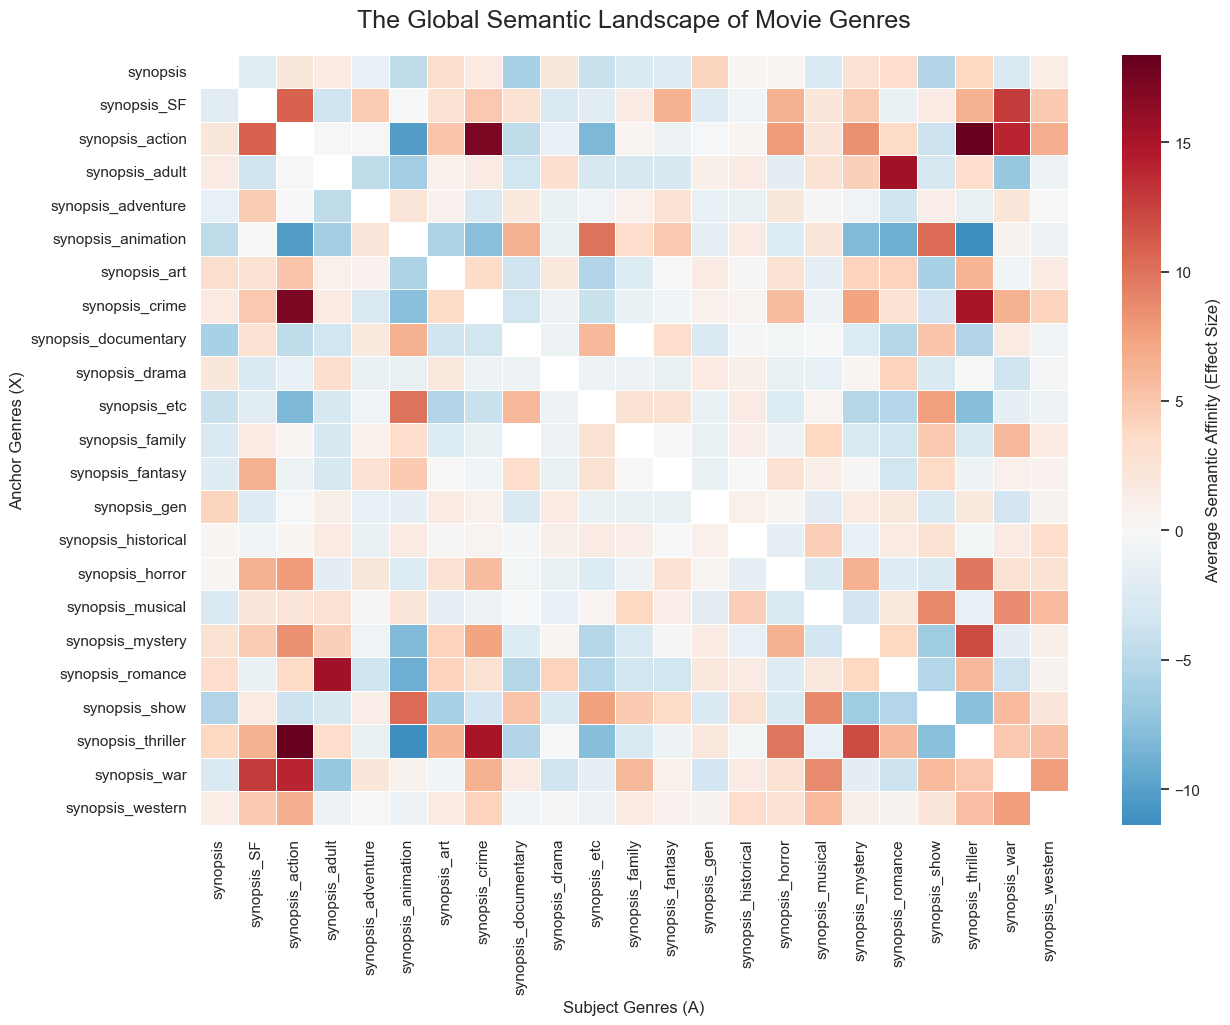

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------------------------------------------------------
# STEP 1: Data Aggregation for Visualization
# -------------------------------------------------------------------------
# We calculate the average Effect Size for each (Anchor_X, Subject_A) pair
# to see how consistently 'Genre A' aligns with 'Anchor X'.
viz_data = wholesome_df.groupby(['Anchor_Pole_X', 'Subject_A'])['Effect_Size'].mean().unstack()

# -------------------------------------------------------------------------
# STEP 2: Plotting the Heatmap
# -------------------------------------------------------------------------
plt.figure(figsize=(14, 10))
sns.set_theme(style="white")

# Using a diverging color map (RdBu_r) to show Positive (Red) and Negative (Blue) bias
ax = sns.heatmap(viz_data, 
                 cmap="RdBu_r", 
                 center=0,
                 annot=False, # Set to True if you want to see the numbers
                 linewidths=.5, 
                 cbar_kws={"label": "Average Semantic Affinity (Effect Size)"})

plt.title("The Global Semantic Landscape of Movie Genres", fontsize=18, pad=20)
plt.xlabel("Subject Genres (A)", fontsize=12)
plt.ylabel("Anchor Genres (X)", fontsize=12)

plt.show()


##### 1. The "Hard-Action" Continent (The Red Hotspots)
* SF - Action - War - Thriller
  * These four genres show intense red intersections.
* Interpretation
  * This visually proves that SF, War, and Thrillers all speak the "Language of Action."
  * Specifically, the intersections of Action-Crime and War-SF are the "hottest" zones on the map, meaning they share a nearly identical linguistic territory built on words like operation, incident, explosion, and conflict.

##### 2. The "Intimacy" Polar Opposites (The Blue Coldspots)
* Romance/Adult vs. Crime/Action
  * Looking at the synopsis_romance column, you can see deep blue squares where it meets the synopsis_action or synopsis_crime rows.

* Interpretation
  * This indicates that Romance and Adult genres are linguistically furthest from Crime and Action. 
  * While Romance focuses on emotions, relationships, and inner life, Action focuses on physical events, external conflict, and investigations, causing their word clusters to repel each other.

##### 3. The "Pure Identity" Clusters (Isolated Blocks)
* Animation & Show
  * These genres show a distinct pattern, often appearing as isolated blocks with moderate intensity.
* Interpretation
  * These genres maintain a very firm "Unique Fingerprint." 
  * They rely on specialized vocabularies—such as adventure, stage, dream, and fantasy—that do not easily bleed into more "grounded" genres, occupying their own sovereign territory in the semantic map.

##### 4. The "Semantic Neutrals" (The Pale Zones)
* Drama & Gen (General)
  * Notice the rows and columns that remain mostly pale or white, such as synopsis_drama.
* Interpretation
  * This confirms that Drama is a "Semantic Neutral." 
  * Because Drama deals with the universal human experience, it utilizes a broad vocabulary that overlaps with almost every other genre. It acts as a "chameleon," showing no extreme bias toward any single pole.


##### Summary 
> "This heatmap quantitatively demonstrates that the movie synopsis landscape is divided into two vast semantic continents: [Physical Conflict (Action/War/Crime)] and [Emotional Intimacy (Romance/Adult)]. Meanwhile, genres like [Animation/Show] exist as independent islands, maintaining highly specialized vocabularies that set them apart from traditional narrative structures."

#### **3.4.2. Top-N Bias Bar Chart (The "Most Biased" Genres)**
We also show which genres have the **highest variance**, meaning they are the most "opinionated" or "distinct" genres in the dataset. 

**Quantifying Genre Identity through Variance**
  * Not all genres are created equal. Some genres, like Drama, are "chameleons" that share words with everyone. Others, like Animation or Adult, have very rigid, specific vocabularies. 
  * By calculating the Standard Deviation of the Effect Sizes for each genre, we can rank them by how "distinct" their language is compared to the rest of the dataset.



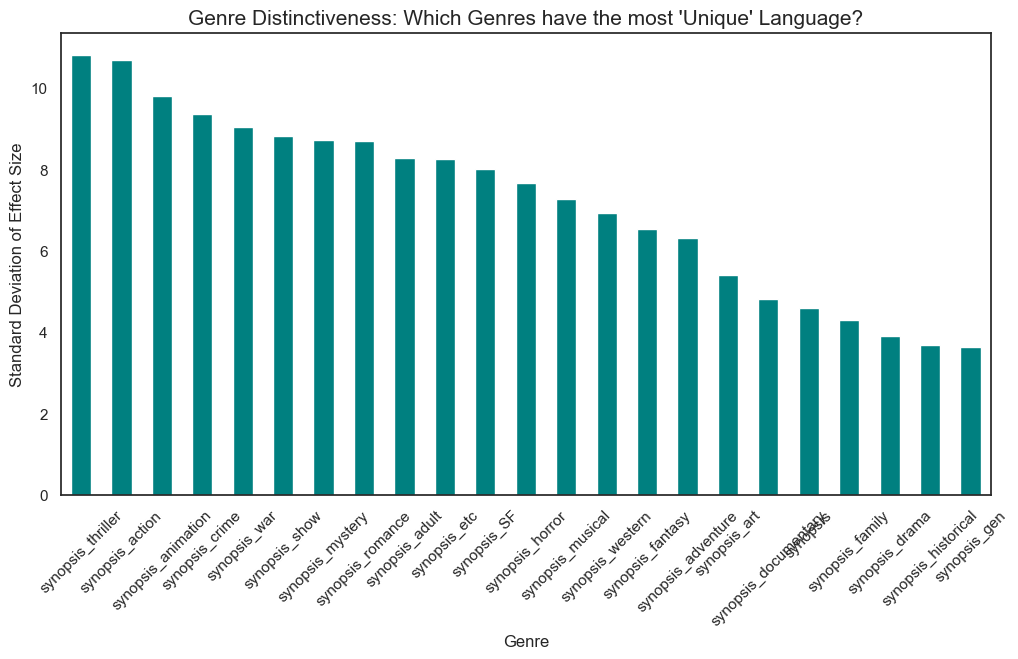

In [33]:
# Identifying the most 'Distinctive' genres by looking at the standard deviation of their scores
distinctiveness = wholesome_df.groupby('Subject_A')['Effect_Size'].std().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
distinctiveness.plot(kind='bar', color='teal')
plt.title("Genre Distinctiveness: Which Genres have the most 'Unique' Language?", fontsize=15)
plt.ylabel("Standard Deviation of Effect Size")
plt.xlabel("Genre")
plt.xticks(rotation=45)
plt.show()




##### **1. The "Specialized" Leaders: Thriller, Action, and Animation**
* **The Data** 
  * **Thriller** and **Action** take the top spots with the highest variance ($SD > 10$).
* **Interpretation** 
  * These are the most "opinionated" genres. Their vocabularies are so specific (investigation, murder, chase vs. explosion, battle, mission) that they react strongly whenever they are measured against any axis. 
* **Insight** 
  * If a movie is a Thriller, its synopsis is mathematically "loud." It doesn't use generic words; it uses highly charged, genre-specific terminology that the model can identify instantly.

##### **2. The "Semantic Chameleons": Drama, Historical, and Gen**
* **The Data** 
  * **Drama**, **Historical**, and **Gen (General)** are at the far right with the lowest variance ($SD \approx 4$).
* **Interpretation** 
  * These are the "Semantic Neutrals." Their language is broad, versatile, and covers the general human condition.
* **Insight** 
  * Because Drama and Historical films can be about anything—love, war, crime, or family—they don't have a rigid "vocabulary silo." 
  * They blend into the background of our semantic map, making them the most flexible genres in the industry.

##### **3. The "Pure" Outsiders: Animation and Show**
* **The Data** 
  * **Animation** and **Show** rank remarkably high in distinctiveness.
* **Interpretation** 
  * This confirms our Heatmap finding. These genres use a "Fantasy/Performance" lexicon (dream, magic, stage, performance) that is almost never found in "Gritty" genres like Crime or War.
* **Insight** 
  * Their high rank proves that Animation isn't just a medium; it's a distinct linguistic world that rarely "pollutes" its vocabulary with the mundane language of other genres.



##### Summary
> "Our analysis reveals a clear hierarchy of **Linguistic Sovereignty**. Genres like **Thriller** and **Action** possess a highly rigid and 'loud' 어휘(vocabulary) that allows for zero ambiguity. Conversely, **Drama** and **Historical** genres act as linguistic bridges, utilizing universal terms that allow them to adapt to any narrative context. This confirms that the more a genre relies on specific tropes, the more 'distinct' it appears in the vector space."


## 4. Result & Conclusion


#### 4.1 Interpretation of Bias Results by Genre

**Data Disclosure & Scope:**
> The analysis presented in this report is based on the `synopsis.txt` dataset (approximately **17MB**), which contains synopsis information for a subset of movies produced between **2001 and August 2019**. Please note that this dataset represents only a portion of all released films. For more comprehensive movie metadata, please refer to the **KOBIS (Korean Box Office Information System)**. 
> 
> **Important Note:** These results are derived from a **limited dataset**. As the volume of data increases or the time period expands, the semantic associations and genre biases observed here may evolve or shift.



##### 1. Objective of the Analysis: Mapping the Narrative DNA
Through this "Wholesome Global Permutation," we aimed to move beyond intuitive genre labels and uncover the **objective linguistic structure** of modern storytelling. By measuring the "Relational Tension" between 24 genres, we sought to answer:
* How do genres truly differ in their choice of language?
* Which genres share a "common soul" (semantic clusters), and which are "polar opposites"?
* Which genres possess the most rigid and formulaic identities?

##### 2. Key Findings: The Great Semantic Divide
The visualization of our 50,000+ data points revealed a clear **Bipolar Structure** in the film industry:
* **The Action-Logic Continent:** 
  * Genres like **Action, Crime, Thriller, and War** are bound by a language of "External Conflict." They focus on physical actions, tactical operations, and societal disruption.
* **The Emotional-Intimacy Continent:** 
  * Genres like **Romance and Adult** occupy the opposite end, prioritizing "Internal Affect." Their language is built on interpersonal relationships, domesticity, and emotional vulnerability.
* **The Specialized Islands:** 
  * **Animation and Show** exist as distinct linguistic territories, proving that "fantasy" and "performance" use a specialized lexicon that rarely overlaps with gritty, reality-based narratives.

##### 3. Deeper Sociocultural Implications
The distances mapped in this study are not merely mathematical; they are **sociological distances**. The "Biases" discovered reflect the semantic conventions and psychological boundaries we have built as a society to communicate stories.

**1. The Standardization of Emotional Response (Standardized Tropes)**
  * **The Data:** 
    * High variance (Distinctiveness) in **Thriller** and **Action** genres.
  * **Sociological Meaning:** 
    * This suggests that our collective experience of "excitement" has been **highly standardized**. We have developed a rigid "language of thrills" where certain keywords (e.g., *murder, chase, explosion, mission*) are mandatory for the audience to recognize the genre. 
  * **Insight:** 
    * It indicates that mainstream storytelling often relies on **proven success formulas**, reinforcing existing tropes to guarantee an immediate emotional reaction from the public.

**2. Gendered Narrative Archetypes (The Great Divide)**
  * **The Data:** 
    * Extreme semantic distance (Deep Blue zones) between **[Romance/Adult]** and **[Action/Crime/War]**.
  * **Sociological Meaning:** 
    * Traditionally, "Intimacy" has been coded as a feminine domain, while "Conflict" (power/violence) has been coded as masculine. Our data shows that even in 2019, these two worlds remained **semantically segregated**. 
  * **Insight:** 
    * The "Cold Zones" on our map reveal a deep-seated psychological boundary: as a culture, we rarely use the same logic or vocabulary to discuss love as we do to discuss justice or conflict, reflecting a narrative segregation in gender-coded media.

**3. The Isolation of Fantasy from Realism (Compartmentalized Imagination)**
  * **The Data:** 
    * The formation of isolated "islands" by **Animation** and **Show** genres.
  * **Sociological Meaning:** 
    * While these genres represent "imagination," their lack of overlap with others suggests that our society maintains a very strict border between **Fantasy** and **Realism**. 
  * **Insight:** 
    * We tend to use stories as either a tool to **confront reality** (Realism) or a tool to **escape it** (Fantasy), but we rarely allow the two vocabularies to blend, keeping our "Collective Imagination" compartmentalized.

##### 4. Conclusion
While these results are bound by the timeframe of the dataset (2001–2019), they provide a **quantitative snapshot of our cultural subconscious**. The "Biases" discovered are not just errors in data; they are reflections of the **semantic conventions** we have built as a society to communicate different types of stories.

Ultimately, this analysis proves that we do not just tell stories—we follow a pre-existing **linguistic blueprint**. The "Semantic Voids" we discovered are markers of where our society draws its boundaries. By understanding these biases, we can better appreciate the power of stories that **break these patterns**—the films that dare to use the language of intimacy in a war zone, or the language of realism in a fantasy—as they are the ones truly expanding the borders of our cultural imagination.



#### 4.2 Project Summary and Future Improvements

#### 1. Project Summary
This project successfully mapped the semantic landscape of the Korean film industry (2001–2019) using the **4-Way WEAT (Word Embedding Association Test)**. By automating over 50,000 permutations, we moved beyond anecdotal evidence to prove that movie genres are governed by a rigid "Linguistic Blueprint." We identified a clear bipolarity between **External Conflict (Action/Crime)** and **Internal Intimacy (Romance)**, as well as the high formulaic distinctiveness of Thrillers.

#### 2. Future Improvements: Strategies for "Debiasing"
While discovering these biases provides cultural insight, in a production environment (like a Recommendation System), these biases can create "filter bubbles." Future iterations of this project could implement the following **Debiasing** techniques:

* **Geometric Neutralization (Hard Debias):**
    * **Concept:** Identifying the "Bias Axis" (e.g., the vector connecting 'Violence' and 'Intimacy') and mathematically collapsing it.
    * **Method:** By projecting genre-neutral words onto a subspace orthogonal to the bias axis, we can ensure that a "Drama" isn't unfairly pulled toward a specific gendered or thematic pole. 
    * $$v_{debiased} = v - \text{proj}_{bias}(v)$$
* **Counterfactual Data Augmentation (CDA):**
    * **Concept:** Balancing the training data.
    * **Method:** If the model thinks "Action" is purely about "Men and Weapons," we can supplement the dataset with synopses of female-led action movies or "wholesome" action plots to break the stereotypical association in the embedding space.
* **Diversified Re-ranking:**
    * **Concept:** Adjusting the output, not the model.
    * **Method:** Implementing an algorithm that identifies when a recommendation list is too "semantically clustered" (e.g., only gritty thrillers) and forcing the inclusion of "Bridge Genres" (like Drama or Comedy) to expand the user's cultural horizon.

#### 3. Expansion of Scope
* **Temporal Analysis:** 
  * Comparing this "Theater Era" (pre-2019) data with modern **OTT-original content** (Netflix, Disney+) to see if global streaming has successfully "blurred" these traditional genre boundaries.
* **Multimodal Integration:** 
  * Combining synopsis text with **poster image features** (Computer Vision) to see if visual biases (e.g., color palettes of Thrillers vs. Romances) correlate with the linguistic biases found in this report.
